In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_superstore_sales.csv to cleaned_superstore_sales.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,quantity,discount,profit,year,month,month_name,quarter,profit_margin,shipping_days,sales_per_quantity
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2,0.00,41.9136,2016,11,November,4,0.1600,3,130.9800
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,0.00,219.5820,2016,11,November,4,0.3000,3,243.9800
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0.00,6.8714,2016,6,June,2,0.4700,4,7.3100
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,5,0.45,-383.0310,2015,10,October,4,-0.4000,7,191.5155
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2,0.20,2.5164,2015,10,October,4,0.1125,7,11.1840


In [ ]:
print(df.shape)
print(df.columns)
df.info()

(9994, 28)
Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit', 'year',
       'month', 'month_name', 'quarter', 'profit_margin', 'shipping_days',
       'sales_per_quantity'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   row_id              9994 non-null   int64  
 1   order_id            9994 non-null   object 
 2   order_date          9994 non-null   object 
 3   ship_date           9994 non-null   object 
 4   ship_mode           9994 non-null   object 
 5   customer_id         9994 non-null   object 
 6   customer_name       9994 non-null   object 
 7   segment       

In [ ]:
df.isnull().sum()

,0
row_id,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_id,0
customer_name,0
segment,0
country,0
city,0


In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   row_id              9994 non-null   int64         
 1   order_id            9994 non-null   object        
 2   order_date          9994 non-null   datetime64[ns]
 3   ship_date           9994 non-null   datetime64[ns]
 4   ship_mode           9994 non-null   object        
 5   customer_id         9994 non-null   object        
 6   customer_name       9994 non-null   object        
 7   segment             9994 non-null   object        
 8   country             9994 non-null   object        
 9   city                9994 non-null   object        
 10  state               9994 non-null   object        
 11  postal_code         9994 non-null   int64         
 12  region              9994 non-null   object        
 13  product_id          9994 non-null   object      

In [ ]:
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_orders = df['order_id'].nunique()
total_customers = df['customer_id'].nunique()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)

Total Sales: 2297200.8603000003
Total Profit: 286397.0217
Total Orders: 5009
Total Customers: 793


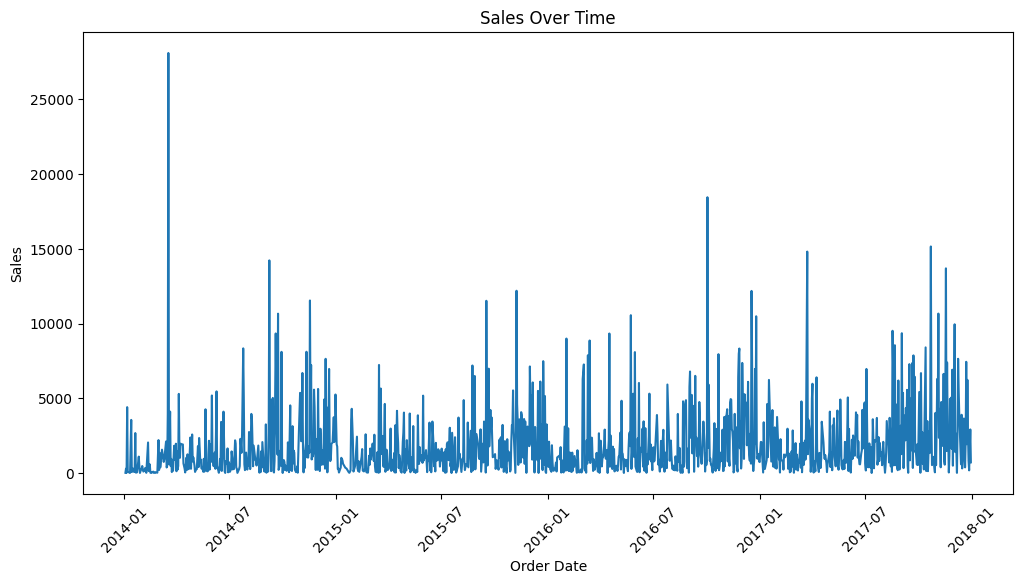

In [ ]:
sales_over_time = df.groupby('order_date')['sales'].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(sales_over_time['order_date'], sales_over_time['sales'])
plt.title('Sales Over Time')
plt.xlabel('Order Date')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

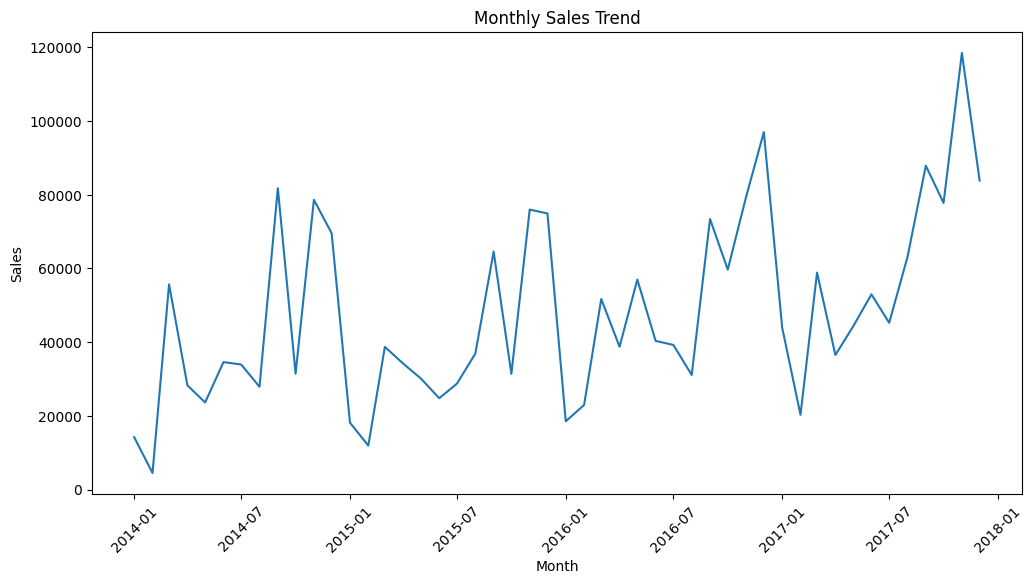

In [ ]:
monthly_sales = df.groupby(['year', 'month'])['sales'].sum().reset_index()
monthly_sales['date'] = pd.to_datetime(monthly_sales[['year', 'month']].assign(day=1))

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales['date'], monthly_sales['sales'])
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

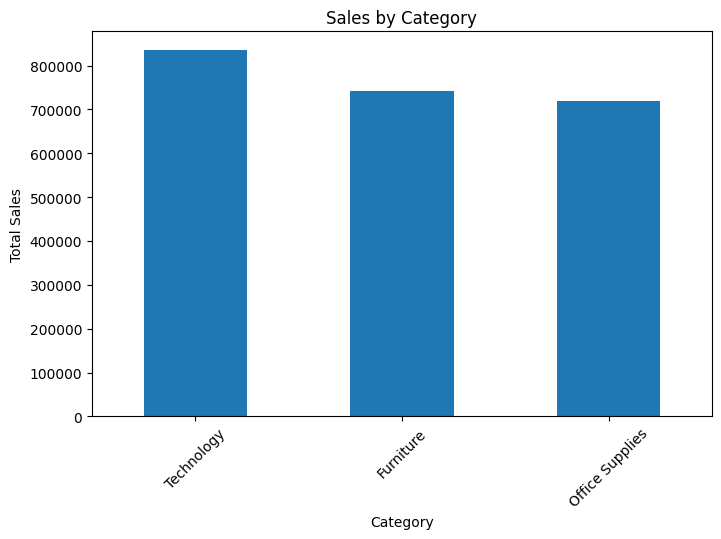

,sales
category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


In [ ]:
sales_by_category = df.groupby('category')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sales_by_category.plot(kind='bar')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

sales_by_category

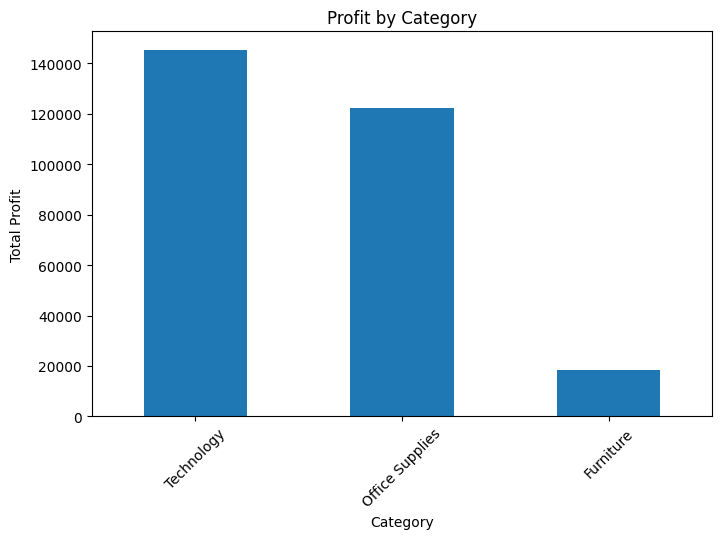

,profit
category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18451.2728


In [ ]:
profit_by_category = df.groupby('category')['profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
profit_by_category.plot(kind='bar')
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.show()

profit_by_category

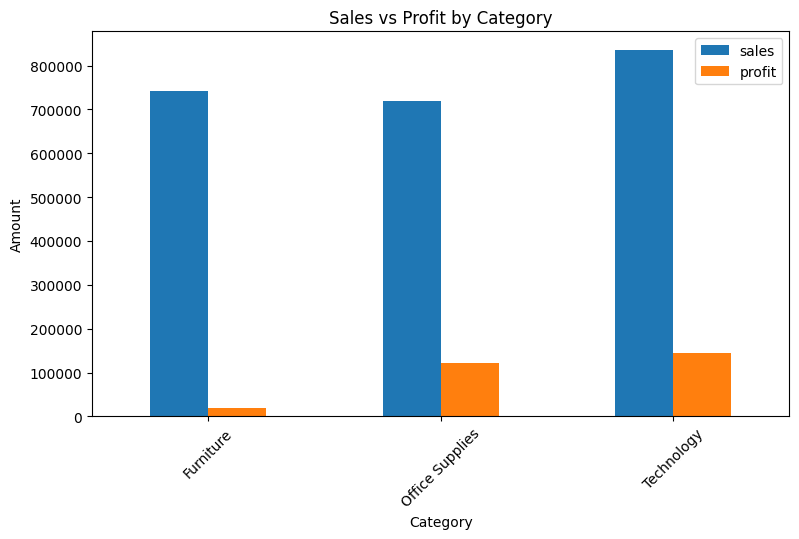

,category,sales,profit
0,Furniture,741999.7953,18451.2728
1,Office Supplies,719047.0320,122490.8008
2,Technology,836154.0330,145454.9481


In [ ]:
category_performance = df.groupby('category')[['sales', 'profit']].sum().reset_index()

category_performance.plot(
    x='category',
    y=['sales', 'profit'],
    kind='bar',
    figsize=(9, 5)
)

plt.title('Sales vs Profit by Category')
plt.xlabel('Category')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.show()

category_performance

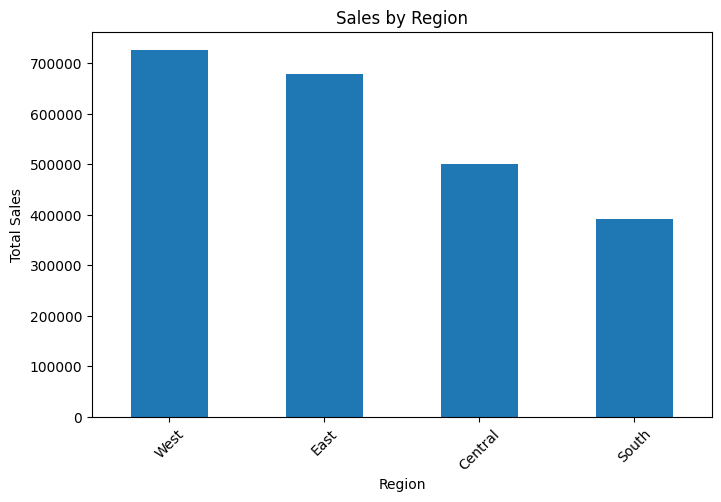

,sales
region,
West,725457.8245
East,678781.2400
Central,501239.8908
South,391721.9050


In [ ]:
sales_by_region = df.groupby('region')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sales_by_region.plot(kind='bar')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

sales_by_region

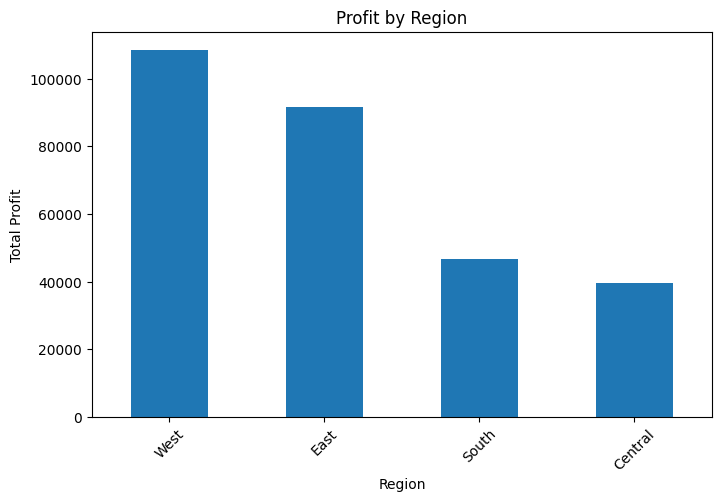

,profit
region,
West,108418.4489
East,91522.7800
South,46749.4303
Central,39706.3625


In [ ]:
profit_by_region = df.groupby('region')['profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
profit_by_region.plot(kind='bar')
plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.show()

profit_by_region



```
Top ten by sales
```




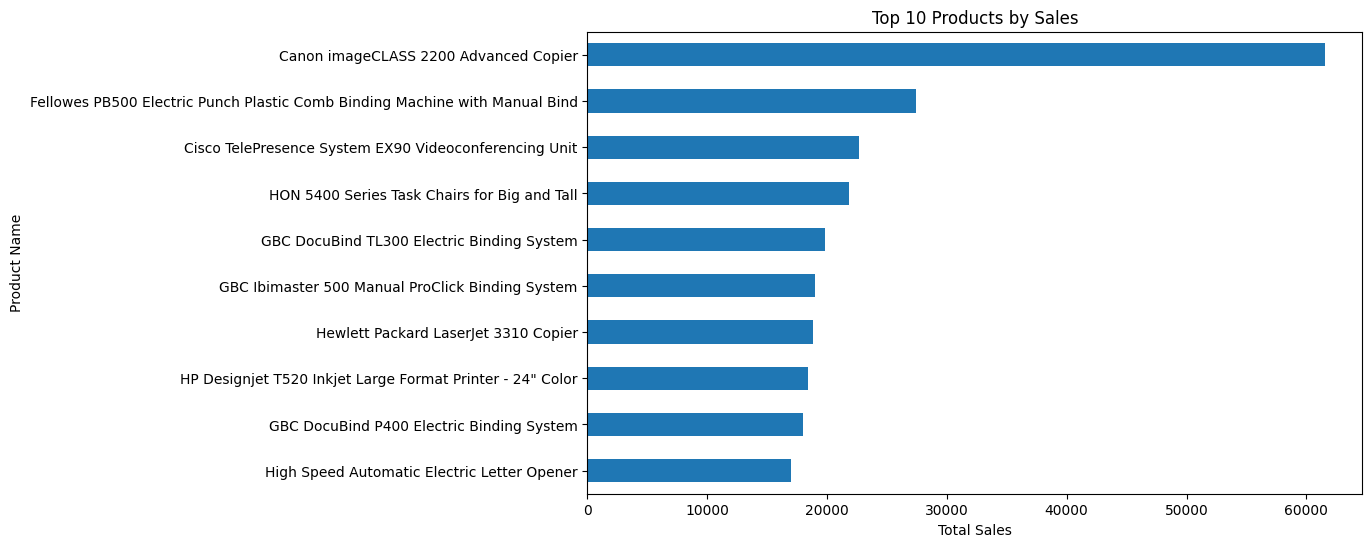

,sales
product_name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


In [ ]:
top_products_sales = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_products_sales.plot(kind='barh')
plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.gca().invert_yaxis()
plt.show()

top_products_sales



```
Top ten by profit
```



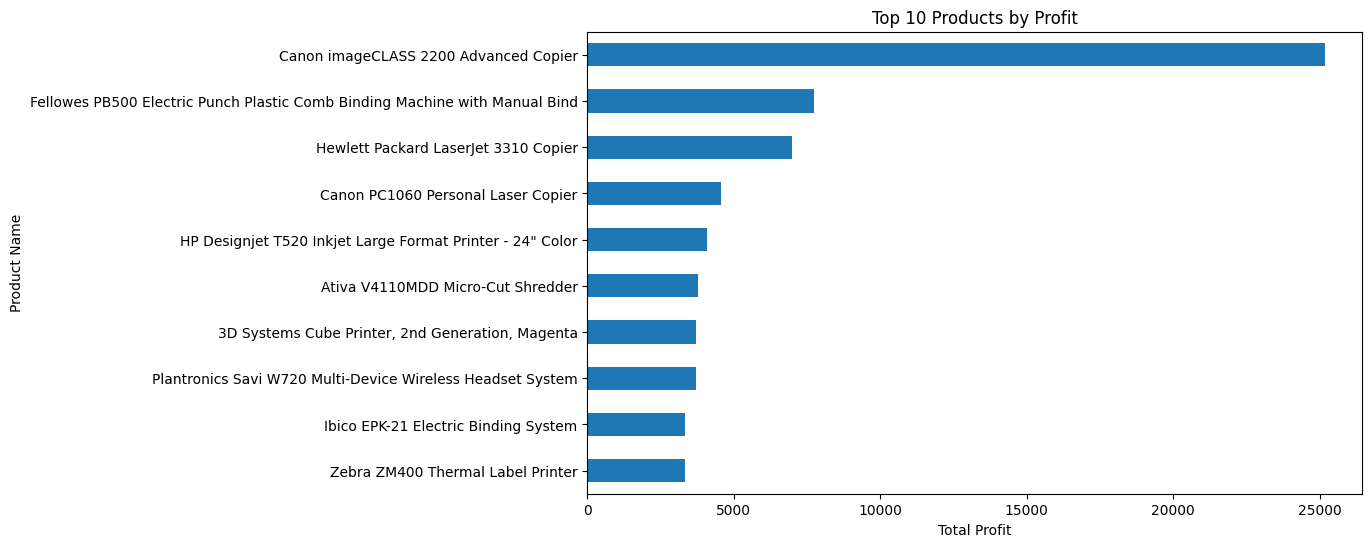

,profit
product_name,
Canon imageCLASS 2200 Advanced Copier,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,7753.0390
Hewlett Packard LaserJet 3310 Copier,6983.8836
Canon PC1060 Personal Laser Copier,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",4094.9766
Ativa V4110MDD Micro-Cut Shredder,3772.9461
"3D Systems Cube Printer, 2nd Generation, Magenta",3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System,3696.2820
Ibico EPK-21 Electric Binding System,3345.2823


In [ ]:
top_products_profit = df.groupby('product_name')['profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_products_profit.plot(kind='barh')
plt.title('Top 10 Products by Profit')
plt.xlabel('Total Profit')
plt.ylabel('Product Name')
plt.gca().invert_yaxis()
plt.show()

top_products_profit



```
worst ten by profit
```



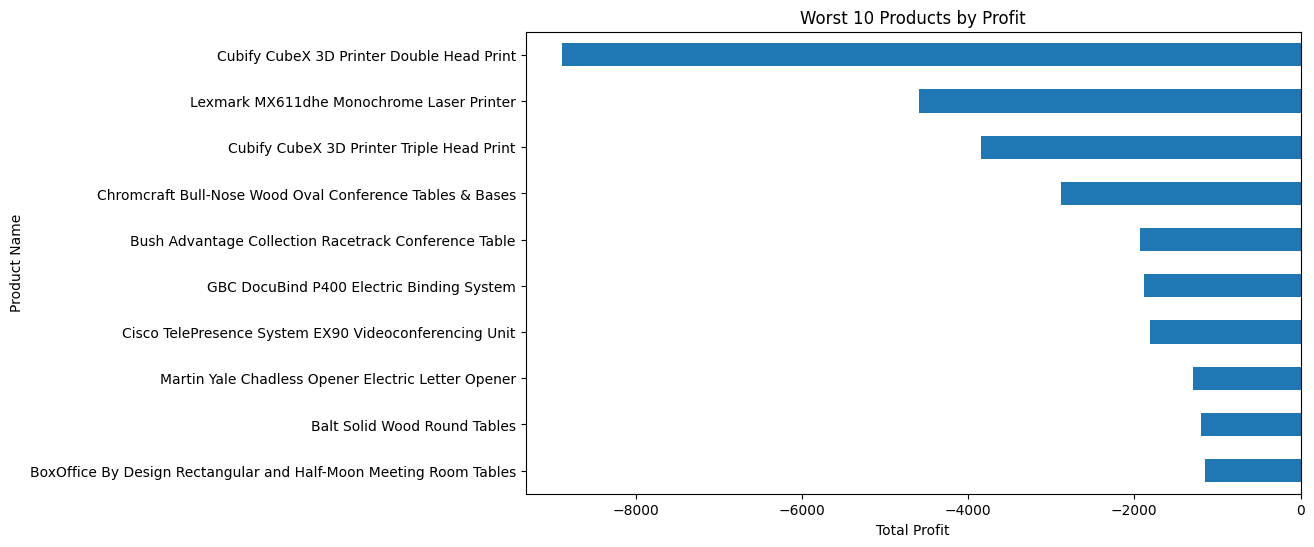

,profit
product_name,
Cubify CubeX 3D Printer Double Head Print,-8879.9704
Lexmark MX611dhe Monochrome Laser Printer,-4589.9730
Cubify CubeX 3D Printer Triple Head Print,-3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,-2876.1156
Bush Advantage Collection Racetrack Conference Table,-1934.3976
GBC DocuBind P400 Electric Binding System,-1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit,-1811.0784
Martin Yale Chadless Opener Electric Letter Opener,-1299.1836
Balt Solid Wood Round Tables,-1201.0581


In [ ]:
worst_products_profit = df.groupby('product_name')['profit'].sum().sort_values(ascending=True).head(10)

plt.figure(figsize=(10, 6))
worst_products_profit.plot(kind='barh')
plt.title('Worst 10 Products by Profit')
plt.xlabel('Total Profit')
plt.ylabel('Product Name')
plt.gca().invert_yaxis()
plt.show()

worst_products_profit



```
discount impact on profit
```



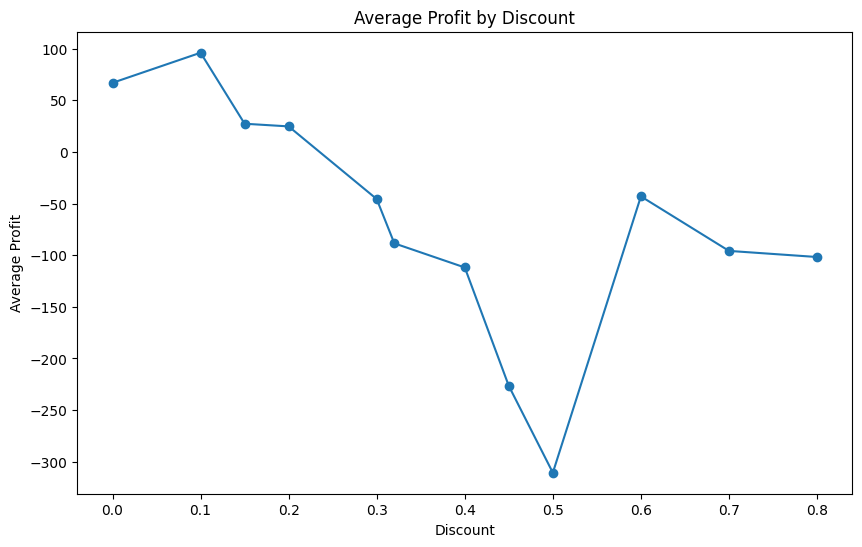

,discount,profit
0,0.00,66.900292
1,0.10,96.055074
2,0.15,27.288298
3,0.20,24.702572
4,0.30,-45.679636
5,0.32,-88.560656
6,0.40,-111.927429
7,0.45,-226.646464
8,0.50,-310.703456
9,0.60,-43.077212


In [ ]:
discount_profit = df.groupby('discount')['profit'].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(discount_profit['discount'], discount_profit['profit'], marker='o')
plt.title('Average Profit by Discount')
plt.xlabel('Discount')
plt.ylabel('Average Profit')
plt.show()

discount_profit



```
discount vs. profit
```



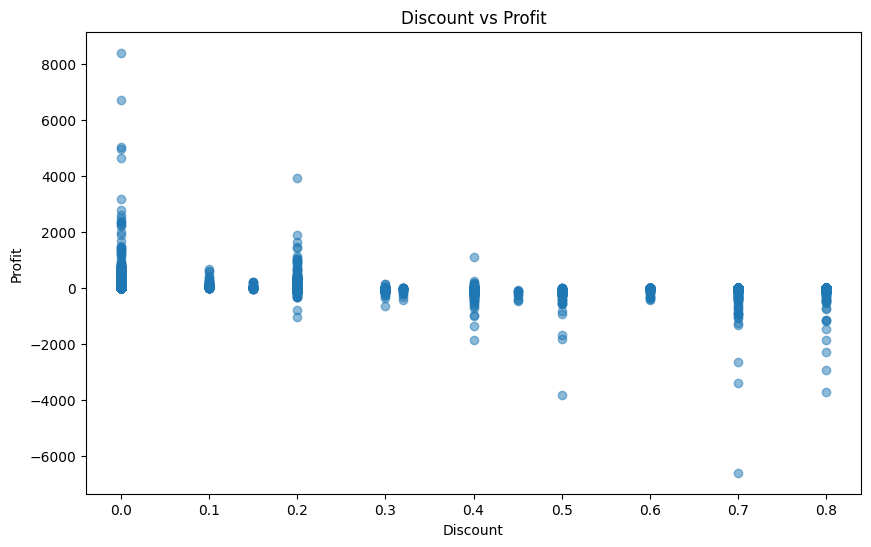

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['discount'], df['profit'], alpha=0.5)
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

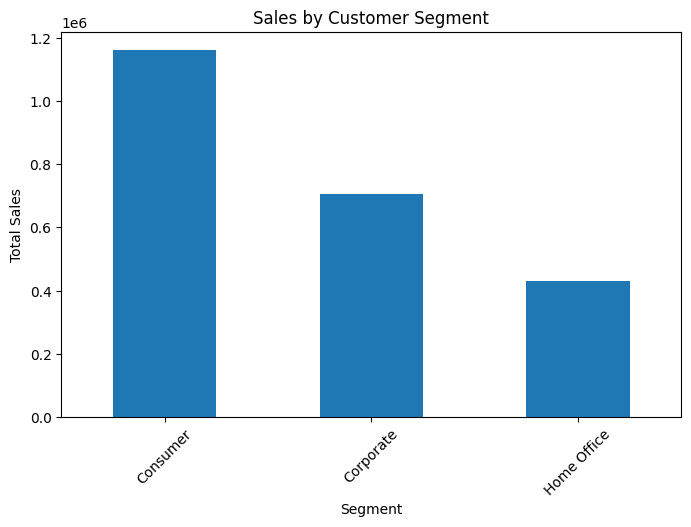

,sales
segment,
Consumer,1.161401e+06
Corporate,7.061464e+05
Home Office,4.296531e+05


In [ ]:
sales_by_segment = df.groupby('segment')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sales_by_segment.plot(kind='bar')
plt.title('Sales by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

sales_by_segment

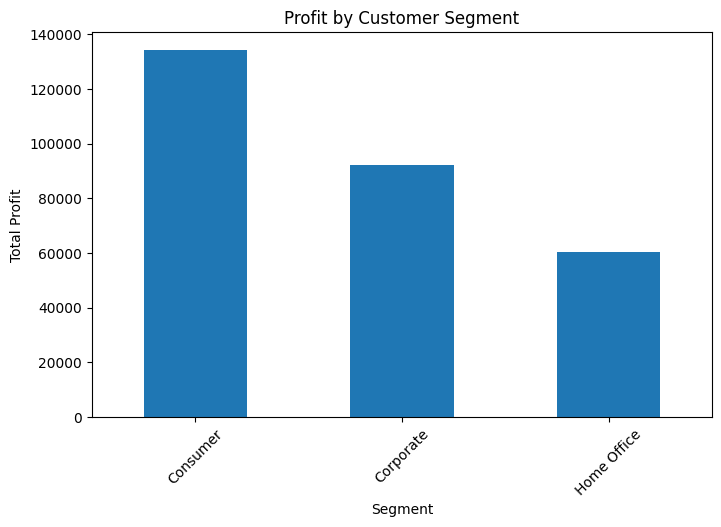

,profit
segment,
Consumer,134119.2092
Corporate,91979.1340
Home Office,60298.6785


In [ ]:
profit_by_segment = df.groupby('segment')['profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
profit_by_segment.plot(kind='bar')
plt.title('Profit by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.show()

profit_by_segment

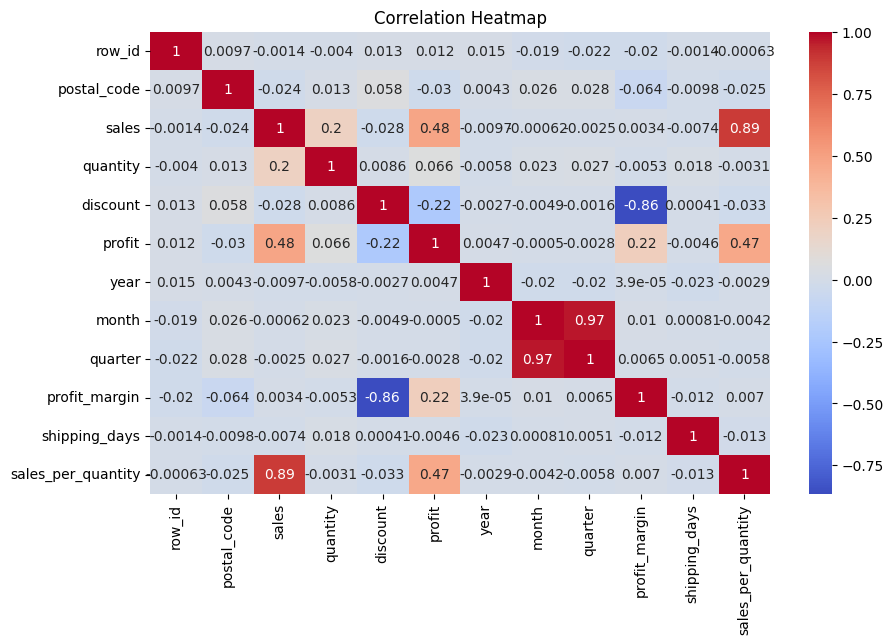

In [ ]:
numeric_columns = df.select_dtypes(include='number')

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_columns.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
eda_summary = pd.DataFrame({
    'Metric': [
        'Total Sales',
        'Total Profit',
        'Total Orders',
        'Total Customers',
        'Best Category by Sales',
        'Best Category by Profit',
        'Best Region by Sales',
        'Best Region by Profit'
    ],
    'Value': [
        total_sales,
        total_profit,
        total_orders,
        total_customers,
        sales_by_category.idxmax(),
        profit_by_category.idxmax(),
        sales_by_region.idxmax(),
        profit_by_region.idxmax()
    ]
})

eda_summary

,Metric,Value
0,Total Sales,2297200.8603
1,Total Profit,286397.0217
2,Total Orders,5009
3,Total Customers,793
4,Best Category by Sales,Technology
5,Best Category by Profit,Technology
6,Best Region by Sales,West
7,Best Region by Profit,West


In [ ]:
eda_summary.to_csv("eda_summary.csv", index=False)
files.download("eda_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
monthly_sales[['year', 'month', 'sales']].to_csv("monthly_sales_for_model.csv", index=False)
files.download("monthly_sales_for_model.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>